# Logistic Regression Example
## Introduction

The general formula of linear regression is familiar to most, and is given by $Y = b_0+b_1 X_1$. Graphically, it represents a linear correlation between two continuous variables ($Y$ and $X_1$). But, what type of formula would we need in order to describe a binary variable?
It turns out that the best formula is logistic regression formula, which, when plotted, will have a sigmoid shape.
Here is a figure showing the distinction between linear and logistic regression:

<img src="https://raw.githubusercontent.com/abdulrahman1123/analysis_examples/main/logistic_reg_intro.png" width=525 height=200 />


The aim of logistic regression modeling is to find the best formula that fits the data the best (i.e. with lowest error possible).

The formula of logistic regression is closely related to that of the linear regression, and is given by:

$$Probability (Y) = \frac{1}{1+e^{-(b_0+b_1 X_1 + b_2 X_2+...)}}$$

where $b_0$ is a constant, $b_1,b_2, ...$ are coefficients multiplied by their respective variables, $X_1, X_2, ...$ are the features in the dataset (AKA columns or variables).


<b>I know, I know! formulas make me anxious too. But don't worry, no manual calculations will be performed, python will take care of it all. In any case, it's good to know the basics.</b>

## L1 Regularization

It is always good to remove irrelevant variables. This makes the model more accurate and less prone to noise. Furthermore, some variables are weakly relevant to the given classification task, and they add only a small amount of predictability in the final model. Removing these variables can have small, and sometimes negligible, effect on the accuracy of the model. It is often adviced to remove these variables and sacrifice small accuracy points, so that the resulting model can be simpler and easier to interpret. So, what can we do to remove irrelevant, or weaklky relevant variables? We need a method to penalize the variables depending on how relevant they are to the classification task at hand. One of the methods is called L1-regularization.

L1-regularization basically assigns values for each of the variables to determine how relevant each of the variables to the final model. This regularization can be made more or less sensitive by modifying its parameter (C). Lower C values mean more sensitivity -> higher chance for variables to be removed. Higher C values mean less sensitivity and so on.

The aim of using regularization at all is to remove irrelevant variables and prevent overfitting

For further information, you can have a look at this [website](https://towardsdatascience.com/l1-and-l2-regularization-methods-ce25e7fc831c) for simplified explanation of L1 regularization.

### When to Use Logistic Regression
Logistic regression is best used when the outcome is binary (i.e. Yes or No). For multiclass classification, one can use multinomial logistic regression, which is a generalization of logistic regression to more than two classes. In this tutorial, we only focus on basic logistic regression. Examples of use cases include:
* Cancer detection: It can be used to detect if a patient has cancer (1) or not (0)
* Test score: Predict if a student passed (1) or failed (0) a test
* Marketing: Predict if a customer will purchase a product (1) or not (0)

## About the Data Used
In this notebook, I will follow the analysis mentioned in the paper [Machine learning in medicine: a practical introduction](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6425557/). The code in that paper is written in R. I translated it to python and modified it a little for the purposes of this course.

For this course, we will use the dataset provided in the paper mentioned above. This dataset was originally publicly available from the paper [Machine Learning Repository of University of California Irvine](http://archive.ics.uci.edu/).

This dataset [consists of characteristics, or features, of cell nuclei taken from breast masses which were sampled using fine-needle aspiration (FNA), a common diagnostic procedure in oncology. The clinical samples used to form this dataset were collected from January 1989 to November 1991.] (Sidey-Gibbons and Sidey-Gibbons 2019) Each sample is then classified as malignant or benign in the 'class' column (1= malignant and 0 = benign).



## Why Error Types Matter in Clinical Prediction

Before we build the model, it's worth pausing on what a "mistake" actually means here. This dataset is about telling malignant breast masses apart from benign ones — so a wrong prediction is not just a number, it has a real clinical consequence.

|  | **Actual: Malignant** | **Actual: Benign** |
|---|---|---|
| **Predicted: Malignant** | True Positive (TP) ✅ | False Positive (FP) — unnecessary biopsy / anxiety |
| **Predicted: Benign** | False Negative (FN) ⚠️ — a missed cancer | True Negative (TN) ✅ |

Notice that the two types of mistakes are *not* equally bad. A false positive leads to extra testing and stress, but a false negative can mean a real cancer goes untreated. This asymmetry is why, in medicine, we rarely judge a model on accuracy alone. Instead, we use these four measures:

* **Sensitivity** (a.k.a. recall): of all patients who *truly* have a malignant tumor, what fraction did the model correctly flag? &nbsp; $\dfrac{TP}{TP+FN}$
* **Specificity**: of all patients who are *truly* benign, what fraction did the model correctly clear? &nbsp; $\dfrac{TN}{TN+FP}$
* **Positive Predictive Value (PPV)**: if the model says "malignant," how likely is that actually true? &nbsp; $\dfrac{TP}{TP+FP}$
* **Negative Predictive Value (NPV)**: if the model says "benign," how likely is that actually true? &nbsp; $\dfrac{TN}{TN+FN}$

<b>Keep this table in mind.</b> We'll build the model first, then come back and compute these exact numbers on real predictions — that's Section 5.1b below.

<i>One more clinical nuance: PPV and NPV also depend on how common the disease is in the population being tested (its prevalence). The same model/test can look much more or less useful depending on whether it's used for general screening (low prevalence) or on patients already referred for a suspicious finding (higher prevalence).</i>


---
## Data Analysis Steps:
### 1. Import libraries and define functions

These are the functions that you will need for your following analyses. <b>This line calls the libraries and functions written in the utils.py file</b>. I kept these functions in another file just for simplicity. You can access it from [THIS LINK](https://github.com/abdulrahman1123/analysis_examples/blob/main/utils.py) if you need.

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import RocCurveDisplay,classification_report, recall_score,confusion_matrix
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="darkgrid")
sns.set_context("paper")

def choose_model(model, c_type = 'best', plot_result = True):
    """
    This function chooses a model from a set of models identified using LogisticRegressionCV
    It can return the best model (model.C_) or the most parsimonious model, which is the model whose score is
    within 1 standard error from the best score
    :param model: logistic regression model with cross validation (LogisticRegressionCV)
    :param c_type: type of C value to return,
                   can be either 'best' for best model, or 'par' for the most parsimonious model
    :param plot_result: whether to plot the reult and show the best model and parsimonious model on the same figure
    :return: C value for the chosen model
    """
    n_folds = model.coefs_paths_[1.0].shape[0]
    c_vals = model.Cs_
    best_c = model.C_

    best_c_ind = np.where(np.abs(c_vals - model.C_) < 1e-10)[0][0]

    included_vars = np.sum(model.coefs_paths_[1.0].mean(axis=0) != 0,  axis=1) - 1  # the -1 is make sure the intercept is not included
    included_vars = included_vars[
        [int(item) for item in np.linspace(0, len(included_vars) - 1, 30)]]  # Take only 30 samples from included_vars
    scores = model.scores_[1.0].mean(axis=0)
    scores_sem = model.scores_[1.0].std(axis=0) / np.sqrt(n_folds)

    # Get 1 standard error of the mean (SEM) from the best accuracy,
    best_sem = scores_sem[best_c_ind]

    # finds the last point where scores are within one SEM from best score
    c1se_ind = np.where(scores[best_c_ind] - scores[0:best_c_ind] < best_sem)[0][0]
    c1se = model.Cs_[c1se_ind]  # least acceptable score
    if plot_result:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax3 = ax.twiny()
        ax3.set_xticks(np.arange(0, len(included_vars) + 2), [''] + list(included_vars) + [''], fontsize = 12)
        ax3.tick_params(width=0, length = 0)
        ax3.set_xlabel('Included Variables', fontsize = 18)
        ax.axvline(x=np.log(best_c), color='grey', ls='-', lw=1, label='Best Score Model')
        ax.axvline(x=np.log(c1se), color='grey', ls='-.', lw=1, label='Parsimonious Model')
        ax.errorbar(np.log(model.Cs_), scores, scores_sem, fmt='o', linewidth=1,
                    color='grey', mfc='royalblue', mec='none', capsize=4)
        ax.legend()
        x_axis_text = np.round(ax.get_xticks()[1:-1],1)
        y_axis_text = np.round(ax.get_yticks()[1:-1],1)
        ax.set_xticks(ticks =x_axis_text, labels =  x_axis_text, fontsize = 12)
        ax.set_yticks(ticks =y_axis_text, labels =  y_axis_text, fontsize = 12)
        ax.set_xlabel('log(C)', fontsize = 18)
        ax.set_ylabel('Accuracy', fontsize = 18)

    if c_type=='best':
        return model.C_[0]
    elif c_type == 'par':
        return c1se
    else:
        raise Warning("c_type can only be set to 'best' or 'par'")


def model_performance(model,X_test,y_test, col_names):
    """
    Print the coefficients and compute accuracy
    :param model: the model to be tested
    :return: print the coeffcieints and compute accuracy
    """
    # let's have a look at the coefficients and see if anything was removed
    print('Coefficients:')
    coefs = [model.intercept_[0]] + list(model.coef_[0])
    coefs = [str(np.round(item,3)) if item!=0 else "-" for item in coefs]
    coef_names = ['intercept'] + list(col_names)[1:-1]
    coefficients = pd.DataFrame(coefs, index=coef_names,columns=['value'])
    print(coefficients)
    print('\n Scores:')

    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    fig, ax = plt.subplots(figsize=(4, 4))
    y_pred_best = model.predict(X_test)
    sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted: Benign', 'Predicted: Malignant'],
                yticklabels=['Actual: Benign', 'Actual: Malignant'], ax=ax)
    ax.set_title('Confusion Matrix - Best Model')
    plt.show()

    return pd.DataFrame([[sens, spec, accuracy]], columns=['Sensitivity', 'Specificity', 'Accuracy'])


def plot_train_test(X_train, X_test, X_val = None):
    """
    Plot the sizes of training and testing datasets for visualization reasons
    :param X_train: Training dataset that contains training subjects as rows
    :param X_test: Testing dataset that contains testing subjects as rows
    :return: plots a stacked horizontal bar plot showing training and testing dataset sizes
    """
    train_size = X_train.shape[0]
    test_size = X_test.shape[0]
    val_size = 0 if np.all(pd.isnull(X_val)) else X_val.shape[0]

    fig, ax = plt.subplots(figsize=(12.5, 1))
    ax.barh(['Data Split'], train_size, edgecolor='black', color='lightsteelblue')
    ax.barh(['Data Split'], val_size, left=train_size, edgecolor='black', color='grey')
    ax.barh(['Data Split'], test_size, left=train_size+val_size, edgecolor='black', color='white')
    ax.text(2, 0, f'Training sample = {train_size} subjects \n(Training the model)',
            size=14, va='center_baseline')
    if not np.all(pd.isnull(X_val)):
        ax.text(train_size + 1, 0, f'Validation = {val_size} subjects\n(finding best parameters)',
            size=14, va='center_baseline')
    ax.text(train_size+val_size + 2, 0, f'Testing sample = {test_size} subjects\n(held-out for final testing)',
            size=14, va='center_baseline')
    ax.set_xticks([]);
    ax.set_yticks([]);
    ax.set_xlabel('');
    ax.set_ylabel('')
    for spine in ax.spines:
        ax.spines[spine].set_visible(False)
    fig.subplots_adjust(left=0.01, right=1, top=0.95, bottom=0.05)
    plt.show()



###
### 2. Load the data



In [43]:
data_dir = 'https://github.com/abdulrahman1123/analysis_examples/raw/main/breast_cancer_wisconsin.csv'
data = pd.read_csv(data_dir)
data['class_name'] = data['class'].replace({0:'Benign',1:'Malignant'})
data

,ID,thickness,cell_size,cell_shape,adhesion,epithelial_size,bare_nuclei,bland_cromatin,normal_nucleoli,mitoses,class,class_name
0,1000025,5,1,1,1,2,1.0,3,1,1,0,Benign
1,1002945,5,4,4,5,7,10.0,3,2,1,0,Benign
2,1015425,3,1,1,1,2,2.0,3,1,1,0,Benign
3,1016277,6,8,8,1,3,4.0,3,7,1,0,Benign
4,1017023,4,1,1,3,2,1.0,3,1,1,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2.0,1,1,1,0,Benign
695,841769,2,1,1,1,2,1.0,1,1,1,0,Benign
696,888820,5,10,10,3,7,3.0,8,10,2,1,Malignant
697,897471,4,8,6,4,3,4.0,10,6,1,1,Malignant


##### 2.1. Have a look at the 'class' variable and plot missing values

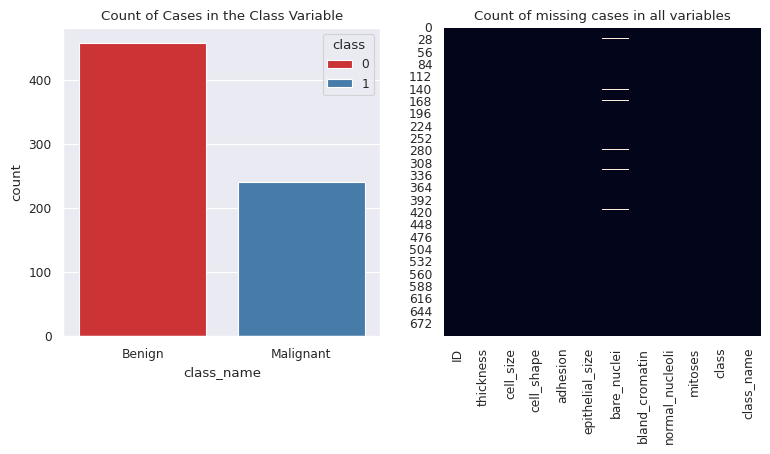

In [44]:
fig,(ax1,ax2) = plt.subplots(nrows = 1, ncols =2, figsize = (9,4))
sns.countplot(x='class_name', hue = 'class',data= data,ax = ax1,palette = sns.color_palette("Set1", 10)[0:2])
ax1.set_title("Count of Cases in the Class Variable")

sns.heatmap(data.isnull(), cbar=False,ax= ax2)
ax2.set_title("Count of missing cases in all variables")

plt.show()

###
### 3. Create training and test datasets

The following generally applies for all machine learning algorithms:

The first step to do is to <b>split your data into training and testing datasets</b>. The training dataset will be used to train the model and evaluate parameters, while the testing dataset will only be used at the end to test how well did the model learn.

The training dataset can be further divided into training and validation datasets, where the validation dataset is used to evaluate the parameters in order to reach to the best model. The way we will be doing this is represented in the following figure from [scikit-learn website](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

<img src="https://scikit-learn.org/stable/_images/grid_search_cross_validation.png" width=440 height=305 />

After splitting the data, we will impute the missing values using the mean of each column. This will be done separately for training and testing datasets.

Then, the data will be normalized (mean = 0 and sd = 1) so that the model can coverge faster (i.e. reach the best solution faster)

Size of training dataset = (524, 9) and testing dataset = (175, 9)


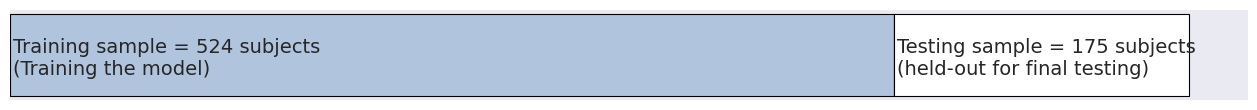

In [26]:
# Choose features
X = data.iloc[:,1:-1]
y = data.iloc[:,-1]

# Divide into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=5)

print(f"Size of training dataset = {X_train.shape} and testing dataset = {X_test.shape}")

# Using the mean, impute the training and testing datasets separately
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
X_train = imp.fit_transform(X_train.copy())
X_test = imp.transform(X_test.copy())


# scale both X_train and X_test for faster convergence
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

plot_train_test(X_train,X_test)

###
### 4. Create and fit the model

To create the best model, we want to use L1-regularization. This is basically a penalty that is applied to the model to remove irrelevant features.

First, let's choose a number of c-values for the model to validate during training. The model will move over the values you provided to find the best value of C for the training dataset. <i>(Note: If you do not provide a list of Cs, it will choose 10 values between 1e-4 and 1e4 by default).</i>


In [27]:
# Choose a number of c-values for the model to test.
c_vals = np.logspace(-3,1, 50) # The smaller the value, the higher the penalty is
print (f"There are {len(c_vals)} C-values, ranging from {c_vals[0]} to {c_vals[-1]}")

cv_model = LogisticRegressionCV(Cs=c_vals,penalty='l1', cv=10, tol=0.001, solver='saga', scoring='accuracy')
# you can also choose scoring = 'neg_mean_squared_error', but remember to multiply scores with -1


print ("\nSearching for best model ...\n")
# fit the model to the training data set
cv_model.fit(X_train,y_train)

print (f"Best model was found. Best C value is {cv_model.C_}")

There are 50 C-values, ranging from 0.001 to 10.0

Searching for best model ...

Best model was found. Best C value is [6.86648845]


### 🧪 Try it yourself: Widening the search range for C

The range we searched above goes from about 0.001 to 10. That was a somewhat arbitrary choice.

* What do you think would happen if we allowed much stronger regularization (much smaller C, e.g. down to 1e-6)? Would you expect *more* or *fewer* features to survive?
* What about allowing much weaker regularization (larger C, e.g. up to 1e3)?

Try changing the range in `np.logspace(...)` below, re-run, and compare the resulting best C to the one found above.


In [33]:
# Try it yourself: widen or narrow the search range for C
c_vals_try = np.logspace(-6, 2, 50)  # original was np.logspace(-3, 1, 50)

cv_model_try = LogisticRegressionCV(Cs=c_vals_try, penalty='l1', cv=10, tol=0.001, solver='saga', scoring='accuracy')
cv_model_try.fit(X_train, y_train)
print(f"Best C value with this range: {cv_model_try.C_}")

# Note: you may see a ConvergenceWarning above with some ranges of C_vals_try -
# that's expected, it just means the optimizer needs more iterations to fully
# converge for some of the values being tested. It doesn't invalidate the result here.


Best C value with this range: [7.19685673]


###
### 5. Show the results
##### 5.1 For the best model
A Table of coefficients will be displayed along with model performance on testing dataset

Coefficients:
                  value
intercept        -1.367
thickness         1.684
cell_size         0.449
cell_shape        1.741
adhesion          0.278
epithelial_size   0.074
bare_nuclei       1.214
bland_cromatin    1.409
normal_nucleoli   0.262
mitoses           0.411

 Scores:


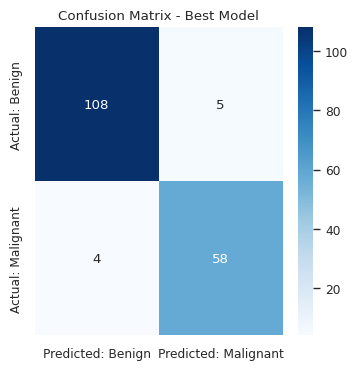

,Sensitivity,Specificity,Accuracy
0,0.935484,0.955752,0.948571


In [39]:
model_performance(cv_model,  X_test, y_test, data.columns)

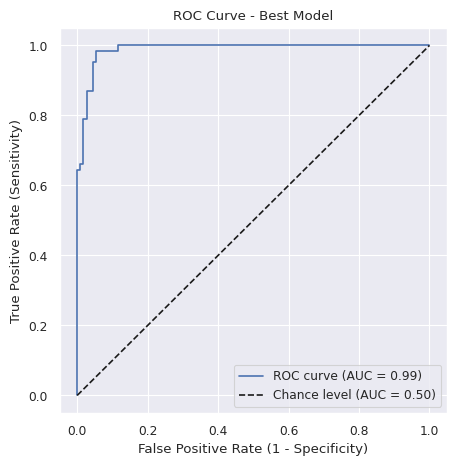

In [40]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax.plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.50)')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve - Best Model')
ax.legend()
plt.show()


##### 5.2 For the most parsimonious model
A Parsimonious model can be chosen by chosing a smaller C value. This C value should have accuracy that lies within one standard error of the mean (SEM) from the best accuracy achieved. Basically, you are choosing a C with very similar performance, yet with less number of variables included. This follows what is used in glmnet package for R.

Coefficients:
                  value
intercept        -1.178
thickness         1.103
cell_size         0.481
cell_shape        0.993
adhesion          0.024
epithelial_size    0.13
bare_nuclei       1.033
bland_cromatin    0.862
normal_nucleoli    0.23
mitoses           0.037

 Scores:


,Sensitivity,Specificity,Accuracy
0,0.919355,0.955752,0.942857


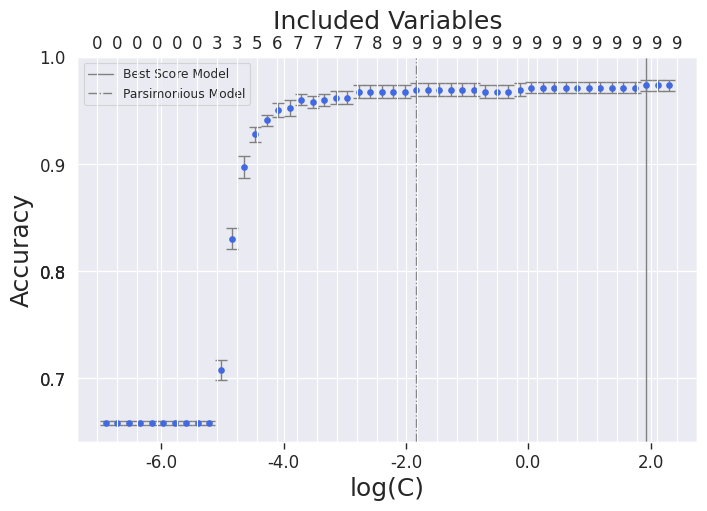

In [29]:
# Choose parsimonious model
par_c = choose_model(model = cv_model,c_type='par', plot_result=True)
par_model = LogisticRegression(C=par_c, penalty='l1', tol = 0.001, solver = 'saga').fit(X_train,y_train)
model_performance(par_model, X_test, y_test,data.columns)

#
# Optional: Logistic Regression using statsmodels library
Sometimes, your aim is not to predict future cases nor is it to comment on the generalizability of the model. In other words, if your aim is to measure the inferential significance of your model. In that case, you would want the traditional logistic regression, where z-values and p-values are computed. This can be done using the statsmodels library, which provides more advanced computations compared to scikit learn, but it is less comprehensive in terms of the options it can provide.

We will apply logistic regression using statsmodels library on the same training dataset we used above, and using the same C value we found above. Please remember two things:

1- the penalty term here is called 'alpha' and is the inverse of the scikit-learn C-value (i.e. $\alpha = \frac{1}{C} $)

2- the solvers used to find the best model are slightly different in the two libraries. So, the values might differ a little bit, but should remain within a close range.

In [30]:
# First, add a constant to your data, because statsmodels does not do that by default
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

alpha = [0] + [1/cv_model.C_[0]]*X_train.shape[1] # This applies 1/C penalty to all variables except for the constant
logit_model = sm.Logit(y_train, X_train_sm).fit_regularized(method='l1', alpha=alpha)

print(logit_model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.06715565671387759
            Iterations: 100
            Function evaluations: 100
            Gradient evaluations: 100
                           Logit Regression Results                           
Dep. Variable:                  class   No. Observations:                  524
Model:                          Logit   Df Residuals:                      514
Method:                           MLE   Df Model:                            9
Date:                Fri, 25 Sep 2026   Pseudo R-squ.:                  0.8987
Time:                        09:21:39   Log-Likelihood:                -34.092
converged:                       True   LL-Null:                       -336.46
Covariance Type:            nonrobust   LLR p-value:                2.023e-124
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

###
### You can also compute model performance on the testing data set

In [32]:
y_pred = logit_model.predict(X_test_sm) # This gives probabilities of y
y_pred_cat = np.where(y_pred>0.5,1,0) # This converts probabilities to either 0 or 1
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cat).ravel()
sens = tp / (tp + fn)
spec = tn / (tn + fp)
accuracy = (tp + tn) / (tp + tn + fp + fn)
pd.DataFrame(np.round([[sens, spec, accuracy]],3), columns=['Sensitivity', 'Specificity', 'Accuracy'])

,Sensitivity,Specificity,Accuracy
0,0.935,0.956,0.949


###
### Awesome! We have similar results as the scikit-learn model above!
###

---
### Further reading:
[Machine learning in medicine: a practical introduction](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6425557/)

[Data Preparation for Machine Learning](https://books.google.de/books?id=uAPuDwAAQBAJ)

[Web page about regularization](https://towardsdatascience.com/l1-and-l2-regularization-methods-ce25e7fc831c)

[Scikit-learn web page about LogisticRegressionCV function](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html)

[Statsmodels web page about logistic regression function with regularization](https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.Logit.fit_regularized.html)